# 8단계. 모델링 데이터셋 구성

- 계획: `docs/modeling_plan.md`
- 입력: `data/cache/features_train.parquet`(Step 4 v2), `data/cache/target_train.parquet`(Step 3 v2)
- 표본: 학습 구간에서 타깃이 있고 거래정지 관련 쌍을 뺀 행(`use`)
- 변수: 초기 세트 28개(`src/modeling.py`의 `FEATURES`). 순위 버전이 아니라 원래 값이다.
- 교차검증: 거래일을 시간 순서로 5개 블록으로 나눈다. 블록 k(2 ~ 5)를 검증할 때 블록 1 ~ k-1로 학습하고(확장 창), 검증 블록 직전 5거래일은 학습에서 뺀다(purge).
- 검증 구간(2026-07 ~ 08)은 만들지 않는다(11단계에서 1회만).
- 산출물: `data/cache/model_dataset.parquet`, `data/cache/model_folds.parquet`

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.modeling import FEATURES, STOCK_FEATURES, MARKET_FEATURES, TARGET, build_dataset, make_blocks, expanding_folds
from src import plotting as P

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 100)
P.setup()

feat = pd.read_parquet(ROOT / "data" / "cache" / "features_train.parquet")
tg = pd.read_parquet(ROOT / "data" / "cache" / "target_train.parquet")
ds = build_dataset(feat, tg)
assert ds.trade_date.max() <= pd.Timestamp("2026-06-30"), "검증 구간 행이 섞였다"
print(f"표본 {len(ds):,}쌍, {ds.trade_date.nunique()}거래일 ({ds.trade_date.min().date()} ~ {ds.trade_date.max().date()}), {ds.symbol.nunique()}종목")
print(f"변수 {len(FEATURES)}개 (종목 {len(STOCK_FEATURES)}, 시장 공통 {len(MARKET_FEATURES)})")

표본 107,880쌍, 540거래일 (2024-04-01 ~ 2026-06-23), 228종목
변수 28개 (종목 22, 시장 공통 6)


## 1. 교차검증 블록과 분할

In [2]:
ds["block"] = make_blocks(ds.trade_date, 5)
blk = ds.groupby("block").agg(start=("trade_date", "min"), end=("trade_date", "max"), days=("trade_date", "nunique"),
                               rows=("symbol", "size"), mdd_mean=(TARGET, "mean"),
                               share_le10=(TARGET, lambda s: (s <= -0.10).mean()))
blk.round(4)

,start,end,days,rows,mdd_mean,share_le10
block,,,,,,
1,2024-04-01,2024-09-05,108,21551,-0.0406,0.0830
2,2024-09-06,2025-02-21,108,21621,-0.0397,0.0704
3,2025-02-24,2025-07-31,108,21552,-0.0383,0.0678
4,2025-08-01,2026-01-12,108,21564,-0.0345,0.0461
5,2026-01-13,2026-06-23,108,21592,-0.0606,0.2058


In [3]:
folds = expanding_folds(ds)
rows = []
for f in folds:
    tr, te = ds.iloc[f["train_idx"]], ds.iloc[f["test_idx"]]
    # purge 검증: 학습 행의 타깃 구간 끝(t+5)이 검증 시작일 이전인가
    days = np.sort(ds.trade_date.unique())
    pos = {d: i for i, d in enumerate(days)}
    gap = pos[te.trade_date.min()] - max(pos[d] for d in tr.trade_date.unique())
    rows.append({"fold": f["fold"], "학습 기간": f"{tr.trade_date.min().date()} ~ {tr.trade_date.max().date()}",
                 "검증 기간": f"{te.trade_date.min().date()} ~ {te.trade_date.max().date()}",
                 "학습 행": len(tr), "검증 행": len(te), "purge 행": f["purged"], "학습 끝 ~ 검증 시작 간격(거래일)": gap})
fold_tab = pd.DataFrame(rows)
assert (fold_tab["학습 끝 ~ 검증 시작 간격(거래일)"] > 5).all(), "purge 부족"
fold_tab

,fold,학습 기간,검증 기간,학습 행,검증 행,purge 행,학습 끝 ~ 검증 시작 간격(거래일)
0,2,2024-04-01 ~ 2024-08-29,2024-09-06 ~ 2025-02-21,20556,21621,995,6
1,3,2024-04-01 ~ 2025-02-14,2025-02-24 ~ 2025-07-31,42172,21552,1000,6
2,4,2024-04-01 ~ 2025-07-24,2025-08-01 ~ 2026-01-12,63724,21564,1000,6
3,5,2024-04-01 ~ 2026-01-05,2026-01-13 ~ 2026-06-23,85288,21592,1000,6


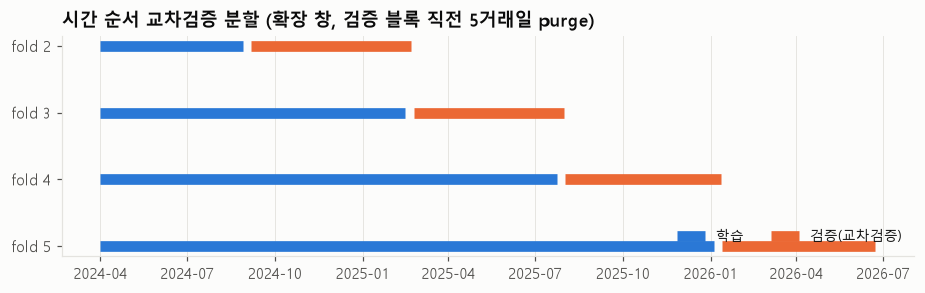

In [4]:
fig, ax = plt.subplots(figsize=(10, 2.6))
for i, f in enumerate(folds):
    tr, te = ds.iloc[f["train_idx"]], ds.iloc[f["test_idx"]]
    y = len(folds) - i
    ax.plot([tr.trade_date.min(), tr.trade_date.max()], [y, y], color=P.SERIES[0], lw=7, solid_capstyle="butt",
            label="학습" if i == 0 else None)
    ax.plot([te.trade_date.min(), te.trade_date.max()], [y, y], color=P.SERIES[1], lw=7, solid_capstyle="butt",
            label="검증(교차검증)" if i == 0 else None)
ax.set_yticks(range(1, len(folds) + 1), [f"fold {f['fold']}" for f in folds][::-1])
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.set_title("시간 순서 교차검증 분할 (확장 창, 검증 블록 직전 5거래일 purge)")
ax.legend(frameon=False, fontsize=9, loc="lower right", ncol=2)
ax.grid(axis="y", visible=False)
P.save(fig, "08_cv_folds")
plt.show()

## 2. 변수 점검

In [5]:
na = ds[FEATURES].isna().mean()
desc = ds[FEATURES].describe(percentiles=[0.01, 0.5, 0.99]).T[["mean", "std", "1%", "50%", "99%"]]
desc.insert(0, "결측률", na)
desc.round(4)

,결측률,mean,std,1%,50%,99%
gk_5,0.0000,0.0246,0.0123,0.0076,0.0218,0.0676
idio_vol_60,0.0010,0.0248,0.0104,0.0094,0.0228,0.0597
skew_60,0.0010,0.2032,0.9283,-2.2218,0.2275,2.7260
past_mdd_60,0.0010,-0.1851,0.0856,-0.4451,-0.1700,-0.0509
n_down3_60,0.0010,0.0963,0.0674,0.0000,0.0833,0.2833
downside_ratio_20,0.0003,0.6621,0.1681,0.2631,0.6703,1.0250
min_intra_drop_20,0.0003,-0.0644,0.0358,-0.1884,-0.0547,-0.0178
dist_low_60,0.0010,0.2214,0.2753,0.0023,0.1409,1.2875
pos_20,0.0003,0.4788,0.2961,0.0046,0.4691,0.9888
ret_20,0.0003,0.0239,0.1475,-0.2547,0.0028,0.5553


In [6]:
# 결측이 있는 행의 출처
miss = ds[FEATURES].isna()
print("결측이 하나라도 있는 행:", f"{miss.any(axis=1).mean():.2%}")
by_sym = ds.loc[miss.any(axis=1)].groupby("symbol").size().sort_values(ascending=False).head(8)
print("결측 행이 많은 종목:", by_sym.to_dict())

결측이 하나라도 있는 행: 0.91%
결측 행이 많은 종목: {'042670': 418, '010620': 397, '489790': 58, '0126Z0': 55, '003410': 49}


In [7]:
# 선택한 종목 변수 간 횡단면 Spearman(겹치지 않는 날짜 평균): 0.7 이상인 쌍
days = np.sort(ds.trade_date.unique())[::5]
sub = ds[ds.trade_date.isin(days)]
R = sum(g[STOCK_FEATURES].rank().corr() for _, g in sub.groupby("trade_date")) / len(days)
pairs = [(a, b, R.loc[a, b]) for i, a in enumerate(STOCK_FEATURES) for b in STOCK_FEATURES[i + 1:] if abs(R.loc[a, b]) >= 0.6]
pd.DataFrame(pairs, columns=["a", "b", "rho"]).sort_values("rho", key=abs, ascending=False).round(3)

,a,b,rho
8,downside_ratio_20,ret_20,-0.851
2,idio_vol_60,n_down3_60,0.763
10,pos_20,ret_20,0.761
12,turnover_20,lend_days_20,-0.700
0,gk_5,idio_vol_60,0.698
7,downside_ratio_20,pos_20,-0.674
3,idio_vol_60,min_intra_drop_20,-0.674
4,past_mdd_60,n_down3_60,-0.663
11,turnover_20,margin_rate,0.648
5,n_down3_60,min_intra_drop_20,-0.641


In [8]:
# 시장 공통 변수 간 시계열 Spearman
mk = ds.drop_duplicates("trade_date").set_index("trade_date")[MARKET_FEATURES]
mk.rank().corr().round(2)

,mkt_vol_20,mkt_ret_20,mkt_ret_60,cs_dispersion_1,breadth_adv_5,mkt_institution_net_20
mkt_vol_20,1.00,0.04,0.40,0.25,0.12,0.15
mkt_ret_20,0.04,1.00,0.64,0.37,0.14,-0.02
mkt_ret_60,0.40,0.64,1.00,0.34,0.10,-0.14
cs_dispersion_1,0.25,0.37,0.34,1.00,0.06,0.00
breadth_adv_5,0.12,0.14,0.10,0.06,1.00,0.04
mkt_institution_net_20,0.15,-0.02,-0.14,0.00,0.04,1.00


In [9]:
# 블록별 변수 분포 변화: 블록 중앙값 (원래 값의 수준 이동 확인)
ds.groupby("block")[["gk_5", "idio_vol_60", "turnover_20", "log_mcap", "mkt_vol_20", "cs_dispersion_1"]].median().round(4)

,gk_5,idio_vol_60,turnover_20,log_mcap,mkt_vol_20,cs_dispersion_1
block,,,,,,
1,0.0198,0.0211,0.0034,28.7695,0.0103,0.0242
2,0.0206,0.0220,0.0031,28.7266,0.0113,0.0257
3,0.0211,0.0219,0.0035,28.8317,0.0110,0.0256
4,0.0197,0.0219,0.0034,28.9987,0.0132,0.0235
5,0.0304,0.0279,0.0048,29.2818,0.0328,0.0335


## 3. 저장

In [10]:
ds.to_parquet(ROOT / "data" / "cache" / "model_dataset.parquet", index=False)
fold_rows = [{"fold": f["fold"], "role": r, "row": i} for f in folds for r, idx in (("train", f["train_idx"]), ("test", f["test_idx"])) for i in idx]
pd.DataFrame(fold_rows).to_parquet(ROOT / "data" / "cache" / "model_folds.parquet", index=False)
print(ds.shape, "-> data/cache/model_dataset.parquet |", len(fold_rows), "행 -> data/cache/model_folds.parquet")

(107880, 33) -> data/cache/model_dataset.parquet | 298069 행 -> data/cache/model_folds.parquet


## 4. 요약과 9단계로 넘길 사항

- **표본**: 107,880쌍, 540거래일(2024-04-01 ~ 2026-06-23), 228종목. 변수 28개(종목 22, 시장 공통 6).
- **교차검증**: 블록 5개(각 108거래일)로 나눴다. 검증 fold는 4개(블록 2 ~ 5)이고, 각 fold마다 검증 블록 직전 5거래일(약 1,000행)을 학습에서 뺐다. 학습 끝과 검증 시작의 간격이 모두 6거래일이라, 학습 타깃이 검증 기간 가격을 쓰지 않는다.
- **블록 5(2026-01-13 ~ 06-23)는 다른 국면이다.**
  - 평균 MDD_5는 -6.1%(다른 블록 -3.5 ~ -4.1%)이고, ≤ -10% 비율은 20.6%(다른 블록 4.6 ~ 8.3%)다.
  - 변수 수준도 크게 움직였다. `gk_5` 중앙값은 약 1.5배, `mkt_vol_20`은 약 2.5배 올랐다.
  - fold 5는 사실상 "평온한 시기로 학습해 충격 국면을 예측하는" 외삽 시험이다. 검증 구간(2026-07 ~ 08)도 비슷한 상황일 수 있으므로 fold 5 성능을 따로 중요하게 본다.
- **결측**: 결측이 하나라도 있는 행은 0.91%다. 대부분 폐지·합병 종목(수급 데이터 없음)과 신규 상장 종목(60일 미만)이다. 트리 모델은 그대로 쓰고, 선형 모델은 채움 처리를 한다.
- **9단계에서 볼 것**
  - `downside_ratio_20`과 `ret_20`의 횡단면 상관이 -0.85로 높다. 둘 중 하나를 빼는 실험을 한다.
  - `log_mcap`은 시장 상승과 함께 수준이 계속 올라간다(블록 1 → 5 중앙값 28.8 → 29.3). 날짜별 순위 버전과 비교한다.
  - 점수 환산표는 교차검증 예측이 있는 블록 2 ~ 5(약 86,000행)로 만든다. 블록 1은 학습에만 쓰여서 교차검증 예측이 없다.